# Trade-size distribution

Load every swap (all pools / both DEXes), value each swap in USD via the hourly
price, and build the pooled trade-size distribution. The quantiles of that
distribution are the **reference trade sizes** used by `arbitrage_index.ipynb`.

All logic lives in `arblib`; this notebook only calls it.

In [1]:
from pathlib import Path

from arblib import data_io, sizing, preprocessing, plotting
from arblib.config import TOKENS

CHAIN = "ethereum"
DATA_DIR = Path.cwd() / CHAIN

# Pool every swap into one frame (static-fee pools only); load hourly USD prices.
dfs = data_io.load_pool_csvs(DATA_DIR / "swaps")
swaps = sizing.pooled_swaps(dfs)
prices = data_io.load_usd_prices(DATA_DIR / "prices" / "USD_token_prices.csv")

Loaded: df_uniswap_swap.csv
       amount0               amount1         dex  evt_block_number  \
0   -999266400    334197952309227723  uniswap_v3          24133363   
1     33925490    -11345521500000000  uniswap_v4          24133364   
2  13936469654  -4658615254546375464  uniswap_v3          24133365   
3   -107703773     36025562985474874  uniswap_v3          24133365   
4   -154244910     51582178535019641  uniswap_v4          24133365   

                evt_block_time  evt_index  \
0  2025-12-31 15:00:11.000 UTC         17   
1  2025-12-31 15:00:23.000 UTC          3   
2  2025-12-31 15:00:35.000 UTC        353   
3  2025-12-31 15:00:35.000 UTC         40   
4  2025-12-31 15:00:35.000 UTC        719   

                                         evt_tx_hash  fee  \
0  0x045ccf214364711f41a1e4ebdc460703fb1d3f6ccfae...  100   
1  0x7e40441f67a6ffeb29115fdf3028481faf2a2b9772bf...    0   
2  0xa8e2974554c1b06a7ab79cf43f0764f29ea521b0e1e6...  500   
3  0xa0671b25449576f08044498e74206b1

## 1. Verify token identity ↔ decimals

Guard the units / token-ordering assumptions: every address maps to one
`decimals`, and token0 / token1 are USDC / WETH in every pool.

In [2]:
preprocessing.verify_token_decimals(swaps, TOKENS[CHAIN]["USDC"], TOKENS[CHAIN]["WETH"], 6, 18)

0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 -> 6 decimals
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 -> 18 decimals

OK: token0 (6 dp), token1 (18 dp) consistent across all pools.


## 2. Human + USD amounts

Normalize raw integer amounts to human units and value each leg in USD at the
swap's block-hour rate, so USDC-in and WETH-in swaps are comparable.

In [3]:
swaps = sizing.add_usd_amounts(swaps, prices)
swaps[["hour", "amount0_h", "amount0_usd", "amount1_h", "amount1_usd"]].head()

,hour,amount0_h,amount0_usd,amount1_h,amount1_usd
0,2025-12-31 15:00:00,-999.266400,-999.556437,0.334198,995.732773
1,2025-12-31 15:00:00,13936.469654,13940.514714,-4.658615,-13880.204392
2,2025-12-31 15:00:00,-107.703773,-107.735034,0.036026,107.337084
3,2025-12-31 15:00:00,-113.077566,-113.110387,0.037844,112.755142
4,2025-12-31 15:00:00,0.686636,0.686835,-0.000229,-0.682206


## 3. Split by direction (the in-leg of each swap)

`amount0 > 0` = USDC in, `amount1 > 0` = WETH in; dust swaps are dropped.

In [4]:
x_in, y_in = sizing.split_in_legs(swaps)

Kept 1118 of 1152 swaps after dust filter
X-in (USDC in): 568 swaps | Y-in (WETH in): 550 swaps


## 4. Trade-size distributions (per leg)

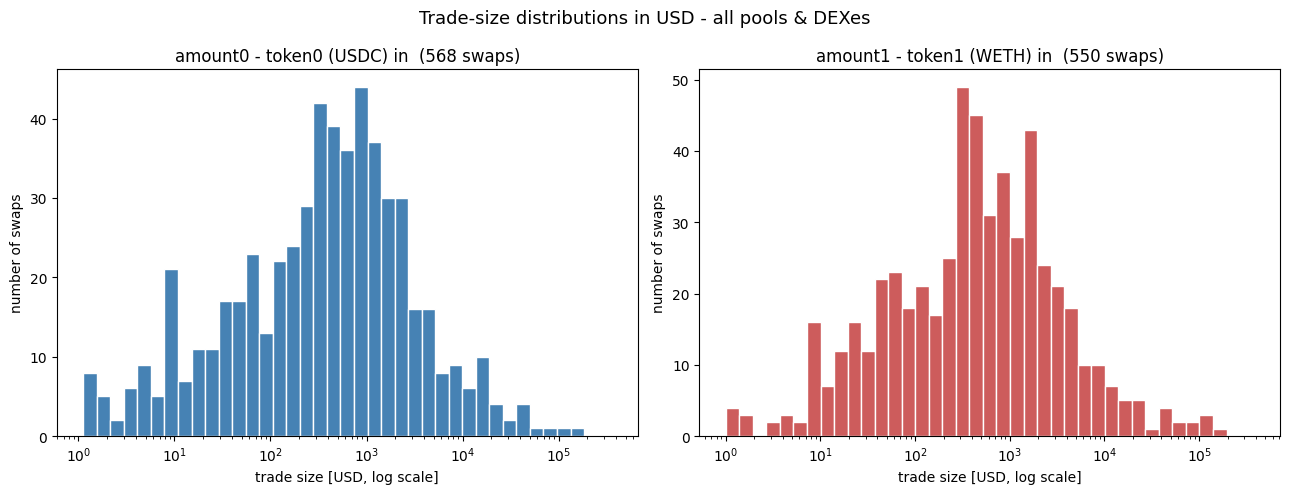

In [5]:
plotting.plot_trade_size_distributions(x_in, y_in)

## 5. Global distribution & reference quantiles

Pool both in-legs into one USD trade-size distribution and take its
20/40/60/80% quantiles as the reference trade sizes.

0.2      55.951689
0.4     297.702052
0.6     712.409333
0.8    1956.443754
dtype: float64


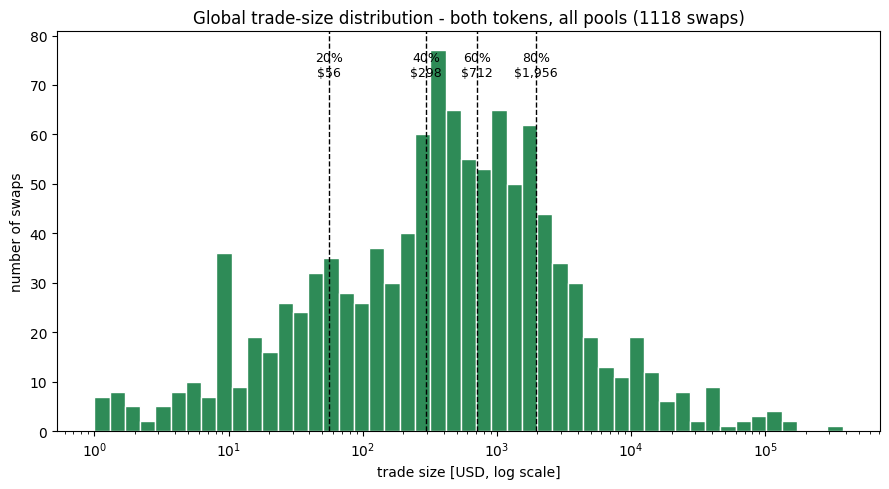

In [6]:
trade_sizes = sizing.pooled_trade_sizes(x_in, y_in)
quantiles = sizing.trade_size_quantiles(trade_sizes, [0.2, 0.4, 0.6, 0.8])
print(quantiles)
plotting.plot_global_trade_size(trade_sizes, quantiles)

## 6. Save the reference trade sizes

Persisted for `arbitrage_index.ipynb` (the next stage in the pipeline).

In [7]:
data_io.save_quantiles(quantiles, DATA_DIR / "trade_size_quantiles.csv")

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/trade_size_quantiles.csv
